In [2]:
import pickle
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

In [3]:
choc_df = pd.read_csv("fake_choc_data.csv")

# Load models
with open("best_precision_xgb_model.pkl", "rb") as f:
    precision_model = pickle.load(f)

with open("best_recall_xgb_model.pkl", "rb") as f:
    recall_model = pickle.load(f)

In [4]:
len(choc_df.columns)

186

In [5]:
import torch
import pandas as pd
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, recall_score
import matplotlib.pyplot as plt

In [6]:
targets = torch.tensor((choc_df['no_show'] == 'Yes').values).float()

In [7]:
X = choc_df.drop(columns='no_show')
X_processed = pd.get_dummies(X, drop_first=True)
inputs = torch.tensor(X_processed.astype(float).values).float()
X_test = inputs.cpu().numpy()
y_test = targets.cpu().numpy()



In [8]:
X_processed.columns.shape

(215,)

In [9]:
X_test.shape


(68907, 215)

In [10]:
y_test.shape

(68907,)

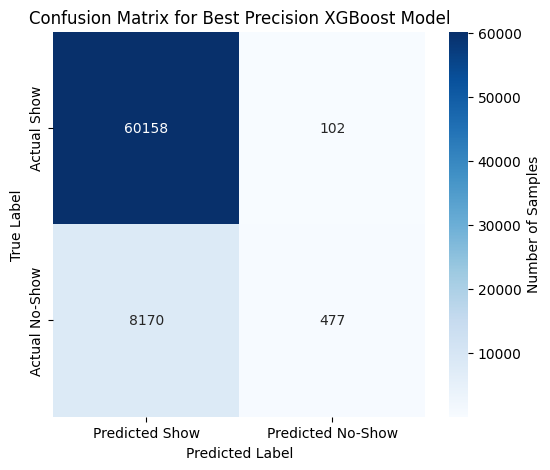

Precision score of the model with highest precision parameters on the test set: 0.8238
Recall score of the model with highest precision parameters on the test set: 0.0552
F1 score of the model with highest precision parameters on the test set: 0.1034


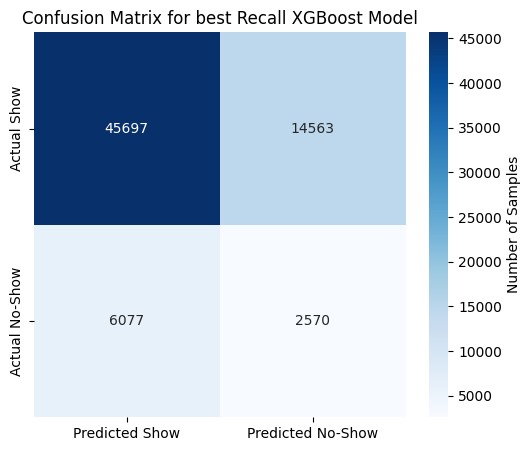

Precision score of the model with highest precision parameters on the test set: 0.1500
Recall score of the model with highest precision parameters on the test set: 0.2972
F1 score of the model with highest precision parameters on the test set: 0.1994


In [12]:
precision_preds = precision_model.predict(X_test)
recall_preds = recall_model.predict(X_test)

# 4. Compute the confusion matrix
cm_precision_model = confusion_matrix(y_test, precision_preds)

# 5. Plot the confusion matrix
plt.figure(figsize=(6, 5)) # Made figure size smaller
sns.heatmap(cm_precision_model, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Show', 'Predicted No-Show'], # Updated labels
            yticklabels=['Actual Show', 'Actual No-Show'], # Updated labels
            cbar_kws={'label': 'Number of Samples'}) # Added color axis title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Best Precision XGBoost Model')
plt.show()

# Print precision, recall, and F1-score for verification on the test set
precision_of_best_precision_model = precision_score(y_test, precision_preds)
recall_of_best_precision_model = recall_score(y_test, precision_preds)
f1_of_best_precision_model = f1_score(y_test, precision_preds)

print(f"Precision score of the model with highest precision parameters on the test set: {precision_of_best_precision_model:.4f}")
print(f"Recall score of the model with highest precision parameters on the test set: {recall_of_best_precision_model:.4f}")
print(f"F1 score of the model with highest precision parameters on the test set: {f1_of_best_precision_model:.4f}")


# 4. Compute the confusion matrix
cm_recall_model = confusion_matrix(y_test, recall_preds)

# 5. Visualize the confusion matrix
plt.figure(figsize=(6, 5)) # Made figure size smaller
sns.heatmap(cm_recall_model, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Show', 'Predicted No-Show'], # Updated labels
            yticklabels=['Actual Show', 'Actual No-Show'], # Updated labels
            cbar_kws={'label': 'Number of Samples'}) # Added color axis title

plt.title(f'Confusion Matrix for best Recall XGBoost Model')
plt.show()

precision_of_best_recall_model = precision_score(y_test, recall_preds)
recall_of_best_recall_model = recall_score(y_test, recall_preds)
f1_of_best_recall_model = f1_score(y_test, recall_preds)

print(f"Precision score of the model with highest precision parameters on the test set: {precision_of_best_recall_model:.4f}")
print(f"Recall score of the model with highest precision parameters on the test set: {recall_of_best_recall_model:.4f}")
print(f"F1 score of the model with highest precision parameters on the test set: {f1_of_best_recall_model:.4f}")